In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv('train.csv')
print(df.head())
print(df['SalePrice'].describe())

   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePrice  
0   2008        WD   

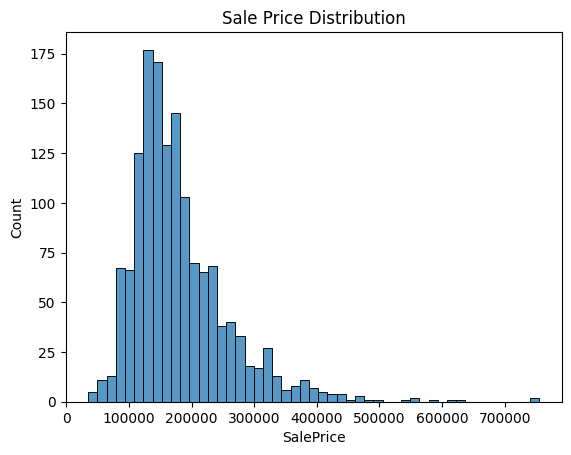

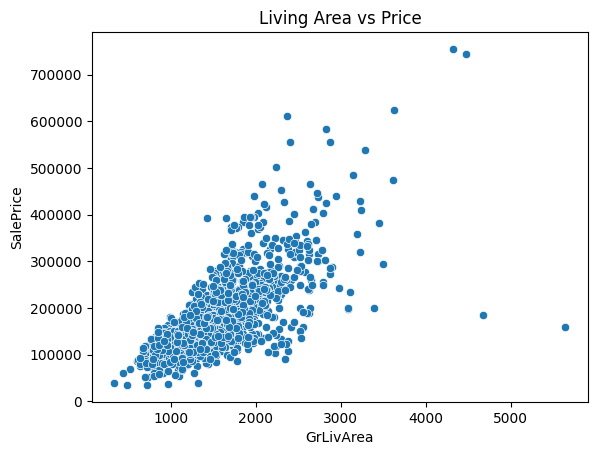

Corr with Price: SalePrice      1.000000
OverallQual    0.790982
GrLivArea      0.708624
GarageCars     0.640409
GarageArea     0.623431
Name: SalePrice, dtype: float64


In [2]:
sns.histplot(df['SalePrice'])
plt.title('Sale Price Distribution')
plt.show()
sns.scatterplot(x='GrLivArea', y='SalePrice', data=df)
plt.title('Living Area vs Price')
plt.show()
print("Corr with Price:", df.corr(numeric_only=True)['SalePrice'].sort_values(ascending=False).head())

In [3]:
df = df[['SalePrice', 'GrLivArea', 'GarageArea', 'YearBuilt', 'OverallQual', 'LotArea', 'MSSubClass', 'MSZoning', 'Neighborhood']]
df.dropna(inplace=True)
le = LabelEncoder()
df['MSZoning'] = le.fit_transform(df['MSZoning'])
df['Neighborhood'] = le.fit_transform(df['Neighborhood'])
print(df.head())

   SalePrice  GrLivArea  GarageArea  YearBuilt  OverallQual  LotArea  \
0     208500       1710         548       2003            7     8450   
1     181500       1262         460       1976            6     9600   
2     223500       1786         608       2001            7    11250   
3     140000       1717         642       1915            7     9550   
4     250000       2198         836       2000            8    14260   

   MSSubClass  MSZoning  Neighborhood  
0          60         3             5  
1          20         3            24  
2          60         3             5  
3          70         3             6  
4          60         3            15  


In [4]:
X = df.drop('SalePrice', axis=1)
y = df['SalePrice']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

RMSE: 30554.706547297403


In [8]:
print(rmse / df['SalePrice'].mean())

0.16888406246112395


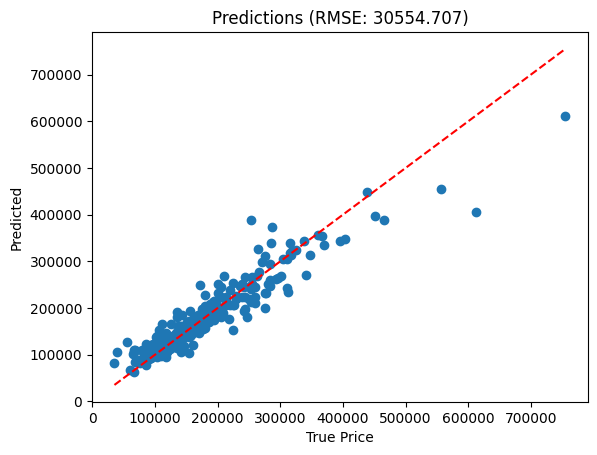

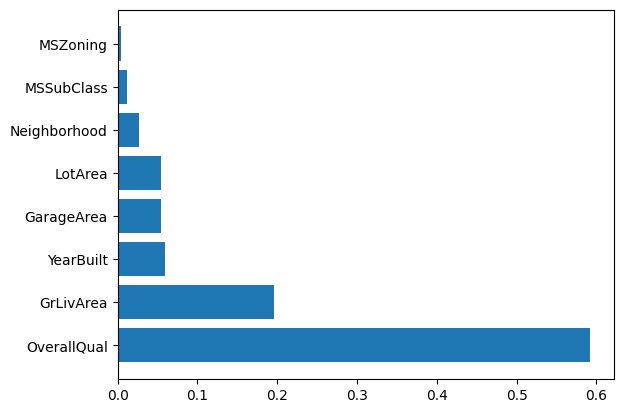

In [5]:
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('True Price'); plt.ylabel('Predicted')
plt.title(f'Predictions (RMSE: {rmse:.3f})')
plt.show()
importances = pd.DataFrame({'Feature': X.columns, 'Imp': model.feature_importances_}).sort_values('Imp', ascending=False)
plt.barh(importances['Feature'], importances['Imp'])
plt.show()